In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [78]:
df = pd.read_csv("raw.csv")

In [79]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [80]:
df.shape

(545, 13)

In [81]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [83]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [84]:
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
num_features = df.select_dtypes(include=np.number).columns

cat_features = df.select_dtypes(exclude=np.number).columns

num_features

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')

In [87]:
cat_features

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [88]:
df[cat_features].nunique()

mainroad            2
guestroom           2
basement            2
hotwaterheating     2
airconditioning     2
prefarea            2
furnishingstatus    3
dtype: int64

In [89]:
for col in cat_features:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 50)

mainroad:
<StringArray>
['yes', 'no']
Length: 2, dtype: str
--------------------------------------------------
guestroom:
<StringArray>
['no', 'yes']
Length: 2, dtype: str
--------------------------------------------------
basement:
<StringArray>
['no', 'yes']
Length: 2, dtype: str
--------------------------------------------------
hotwaterheating:
<StringArray>
['no', 'yes']
Length: 2, dtype: str
--------------------------------------------------
airconditioning:
<StringArray>
['yes', 'no']
Length: 2, dtype: str
--------------------------------------------------
prefarea:
<StringArray>
['yes', 'no']
Length: 2, dtype: str
--------------------------------------------------
furnishingstatus:
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str
--------------------------------------------------


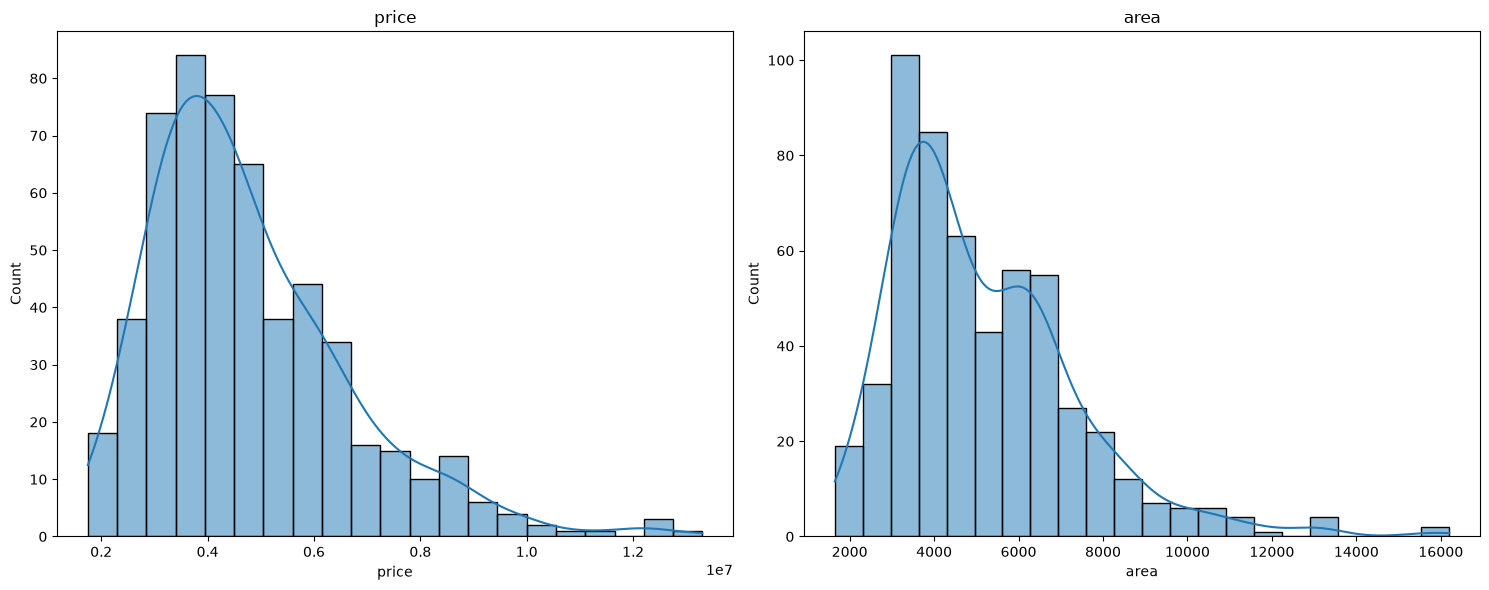

In [90]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(df[['price','area']], 1):
    plt.subplot(1, 2, i)  
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

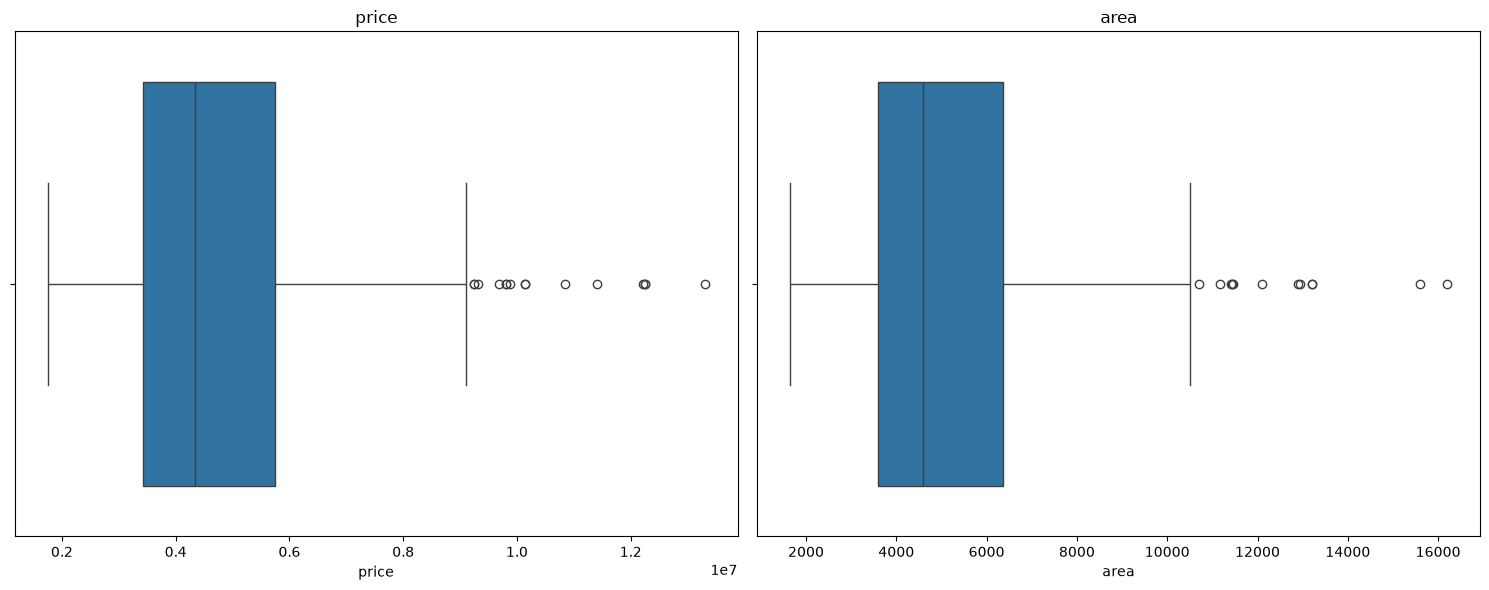

In [91]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(df[['price','area']], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [92]:
df[num_features].skew()

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64

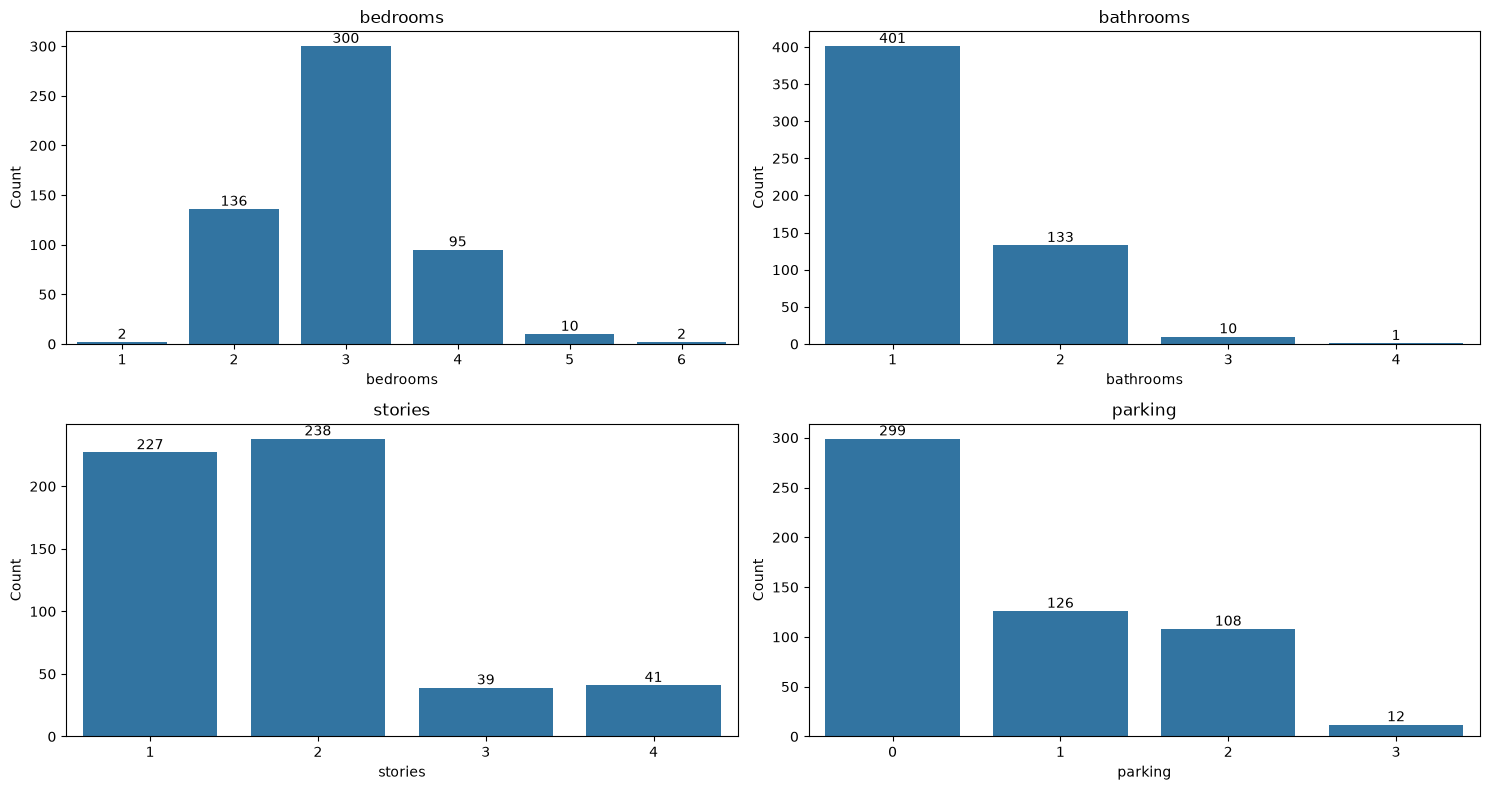

In [93]:
plt.figure(figsize=(15, 8))

cols = ['bedrooms', 'bathrooms', 'stories', 'parking']

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)

    ax = sns.countplot(x=df[col])

    # Add count labels on bars
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [94]:
corr = df[num_features].corr()['price'].sort_values(ascending=False)

corr

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

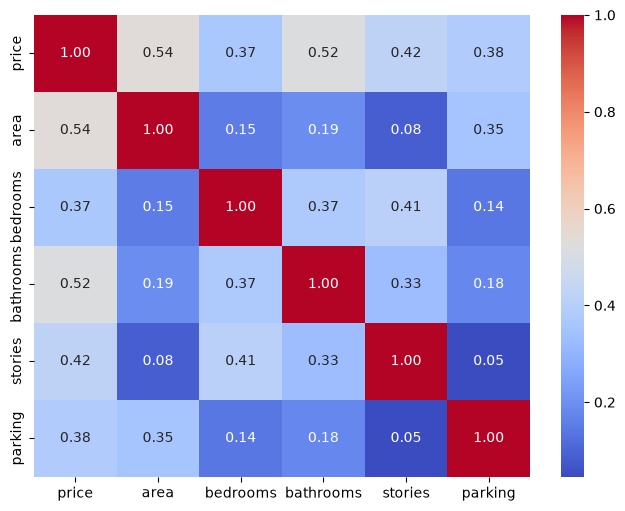

In [95]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [96]:
for col in cat_features:
    print(df.groupby(col)['price'].mean().round(2).sort_values(ascending=False))
    print("-"*30)

mainroad
yes    4991777.33
no     3398904.55
Name: price, dtype: float64
------------------------------
guestroom
yes    5792896.91
no     4544545.62
Name: price, dtype: float64
------------------------------
basement
yes    5242615.18
no     4509965.93
Name: price, dtype: float64
------------------------------
hotwaterheating
yes    5559960.00
no     4728593.15
Name: price, dtype: float64
------------------------------
airconditioning
yes    6013220.58
no     4191939.68
Name: price, dtype: float64
------------------------------
prefarea
yes    5879045.70
no     4425298.78
Name: price, dtype: float64
------------------------------
furnishingstatus
furnished         5495696.00
semi-furnished    4907524.23
unfurnished       4013831.46
Name: price, dtype: float64
------------------------------


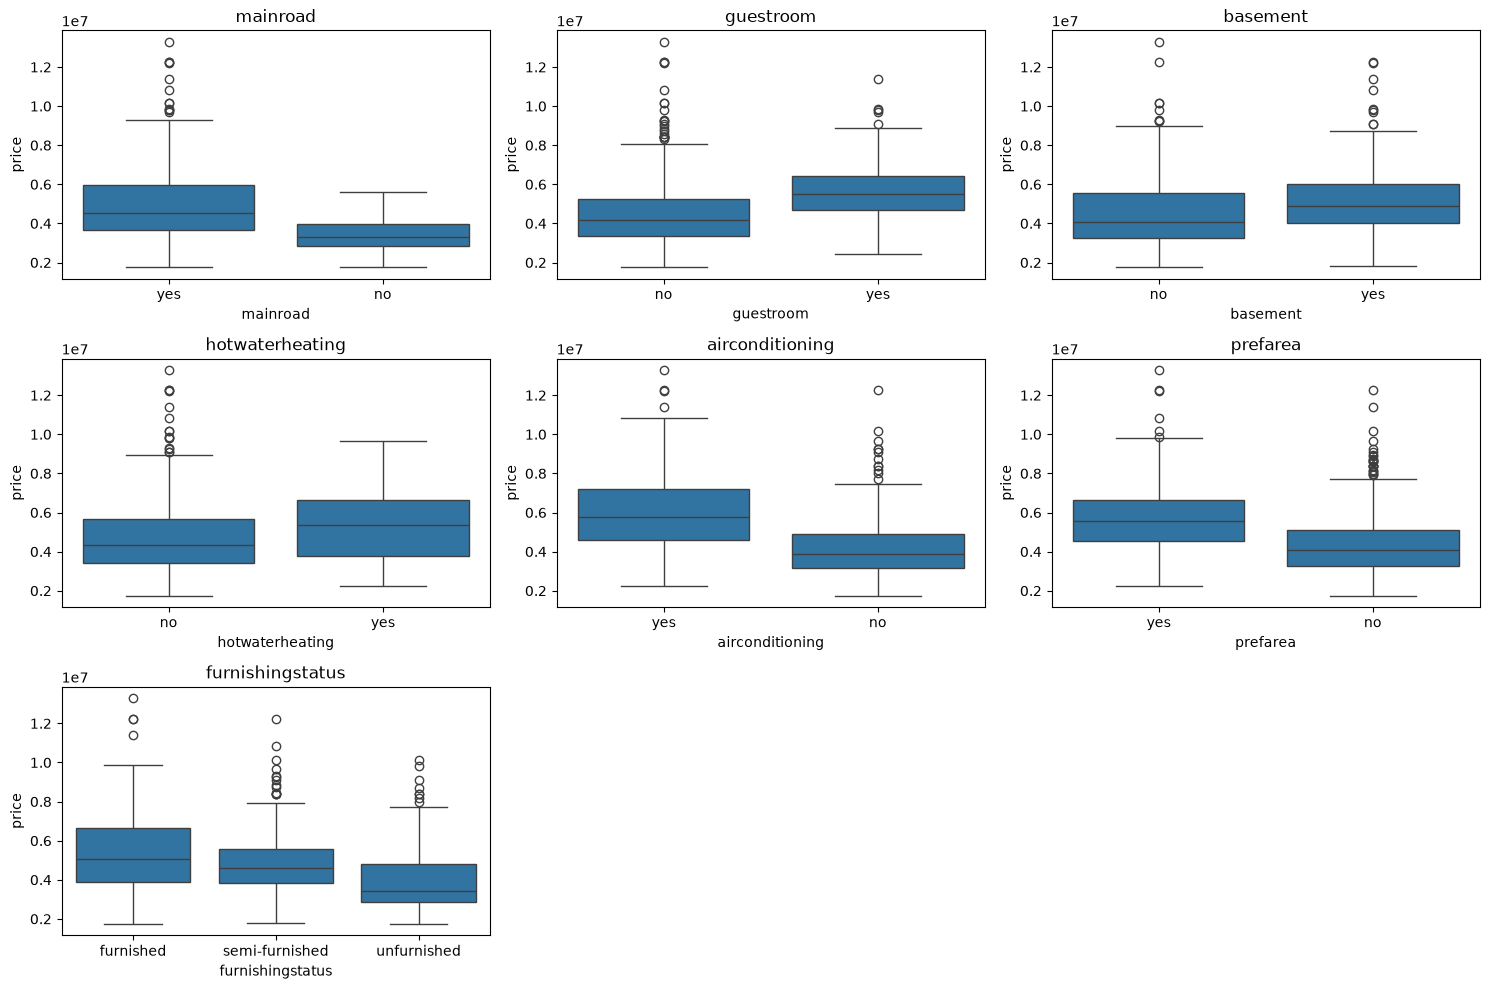

In [97]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], y=df['price'])
    plt.title(col)

plt.tight_layout()
plt.show()

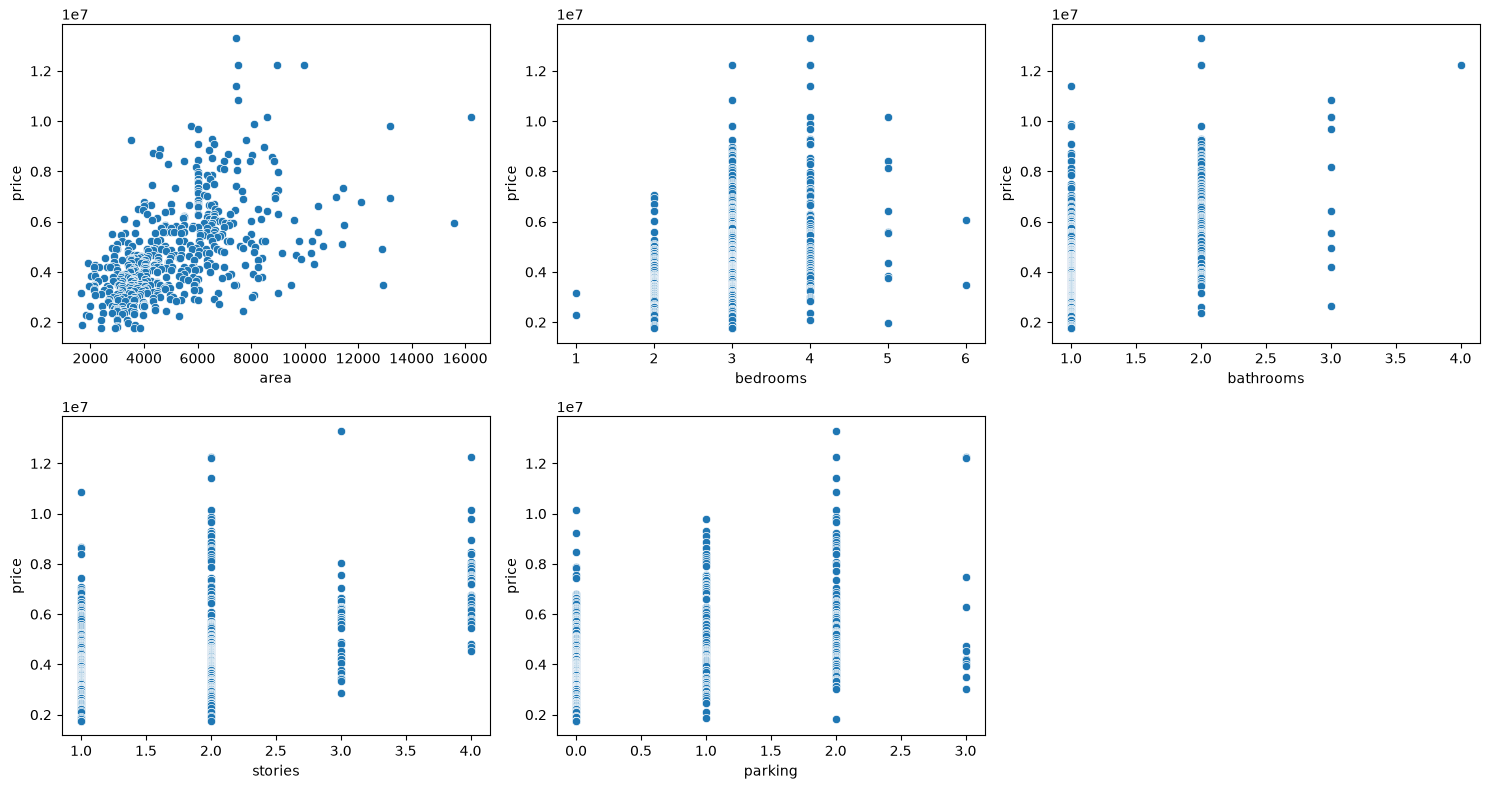

In [98]:
plt.figure(figsize=(15,8))

cols = [col for col in num_features if col != 'price']

for i, col in enumerate(cols,1):
    plt.subplot(2,3,i)
    sns.scatterplot(data=df, x=col, y='price')

plt.tight_layout()
plt.show()

In [100]:
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")

price: 15 outliers
area: 12 outliers
bedrooms: 12 outliers
bathrooms: 1 outliers
stories: 41 outliers
parking: 12 outliers


# 📌 EDA Summary

- The dataset contains **545 observations** and **13 features**, providing sufficient data for building a regression model.
- No **missing values** or **duplicate records** were found, indicating that the dataset is clean and does not require additional data cleaning.
- Most numerical features exhibit **positive (right) skewness**, with `price` and `area` being highly right-skewed.
- **Area** has the strongest positive correlation with the target variable (`price`), followed by **bathrooms** and **stories**, suggesting these features are important predictors of house prices.
- Categorical features such as **air conditioning**, **preferred area**, **guest room**, and **furnishing status** show a noticeable influence on house prices.
- Outliers are present in features such as **price** and **area**. However, these observations likely represent genuine high-value properties rather than data entry errors.
- Since the dataset contains only **545 observations**, removing these outliers could lead to unnecessary information loss. Therefore, the outliers are **retained** for model training.
- The dataset contains several **categorical features**, which will require **encoding** during the preprocessing stage before model training.

## Conclusion

The dataset is clean, well-structured, and suitable for machine learning. The next step is to preprocess the data by encoding categorical variables, splitting the dataset into training and testing sets, and training multiple regression models to identify the best-performing model for house price prediction.